# Sharma et al. (2024) — 2D-CNN Replication

**Paper:** Sharma et al. (2024), *Explainable artificial intelligence for intrusion detection in IoT networks: A deep learning based approach*, Expert Systems with Applications.

This notebook reconstructs the paper's 2D-CNN multi-class intrusion-detection experiment on **NSL-KDD** and **UNSW-NB15**.

> **Replication note:** this is a reconstruction, not the authors' original source code. The paper does not provide enough implementation detail to guarantee bit-for-bit reproduction. Preprocessing/implementation choices that are not available from the paper are explicitly marked **ASSUMPTION**.

**Colab input files:** upload `KDDTrain+.txt`, `KDDTest+.txt`, `UNSW_NB15_training-set.csv`, and `UNSW_NB15_testing-set.csv` using Section 1A. The files are then read from `/content/`.

**Split:** 60% train / 15% validation / 25% test, stratified, seed 42.


In [1]:
# 1. Imports & setup
import os, random, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
EPOCHS = 20
BATCH_SIZE = 128
N_CLASSES = 5
CLASS_NAMES = ["Normal", "DoS", "Probe", "R2L", "U2R"]

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("TensorFlow:", tf.__version__, "| Seed:", SEED)

TensorFlow: 2.20.0 | Seed: 42


## 1A. Upload dataset files (Google Colab)

Run this cell once in a fresh Colab runtime. It uploads the four required dataset files directly into `/content/`, so the later preprocessing cells can use the same fixed paths automatically.

Required files:
- `KDDTrain+.txt`
- `KDDTest+.txt`
- `UNSW_NB15_training-set.csv`
- `UNSW_NB15_testing-set.csv`


## 2. Load & preprocess NSL-KDD

**ASSUMPTION:** because the exact preprocessing cells from the existing 1D-CNN notebook were not available as a file here, this notebook explicitly reconstructs the common pipeline: combine the supplied files, map to 5 classes, remove the paper-reported features, one-hot encode categorical columns, standard-scale numeric features, then split 60/15/25 with seed 42. The encoder/scaler are fit on train only.

The resulting feature vector may not contain exactly 36 values. For the 2D-CNN input, extra values are truncated and missing values are zero-padded to 36, then reshaped to `6×6×1`. This shape conversion is an **implementation assumption**, not a claim about the authors' exact code.


In [3]:
# 2. Load & preprocess NSL-KDD
NSL_TRAIN_PATH = "/content/KDDTrain+.txt"
NSL_TEST_PATH = "/content/KDDTest+.txt"

NSL_COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","attack","difficulty"
]

DOS = {"back","land","neptune","pod","smurf","teardrop","apache2","udpstorm","processtable","mailbomb"}
PROBE = {"satan","ipsweep","nmap","portsweep","mscan","saint"}
R2L = {"guess_passwd","ftp_write","imap","phf","multihop","warezmaster","warezclient",
       "spy","xlock","xsnoop","snmpguess","snmpgetattack","httptunnel","sendmail","named"}
U2R = {"buffer_overflow","loadmodule","rootkit","perl","sqlattack","xterm","ps"}

def nsl_class(x):
    x = str(x).strip().lower().rstrip(".")
    if x == "normal": return "Normal"
    if x in DOS: return "DoS"
    if x in PROBE: return "Probe"
    if x in R2L: return "R2L"
    if x in U2R: return "U2R"
    return "DoS"

assert os.path.exists(NSL_TRAIN_PATH), f"Missing {NSL_TRAIN_PATH}"
assert os.path.exists(NSL_TEST_PATH), f"Missing {NSL_TEST_PATH}"

nsl = pd.concat([
    pd.read_csv(NSL_TRAIN_PATH, header=None, names=NSL_COLUMNS),
    pd.read_csv(NSL_TEST_PATH, header=None, names=NSL_COLUMNS)
], ignore_index=True)

nsl["class"] = nsl["attack"].map(nsl_class)

NSL_DROP = [
    "srv_serror_rate","dst_host_srv_rerror_rate","num_root",
    "dst_host_serror_rate","dst_host_srv_serror_rate","srv_rerror_rate"
]
X_nsl_all = nsl.drop(columns=["attack","difficulty","class"] + NSL_DROP)
y_nsl_all = nsl["class"]

# 60/15/25 stratified split.
X_nsl_train_raw, X_nsl_tmp, y_nsl_train_raw, y_nsl_tmp = train_test_split(
    X_nsl_all, y_nsl_all, test_size=0.40, random_state=SEED, stratify=y_nsl_all
)
X_nsl_val_raw, X_nsl_test_raw, y_nsl_val_raw, y_nsl_test_raw = train_test_split(
    X_nsl_tmp, y_nsl_tmp, test_size=0.625, random_state=SEED, stratify=y_nsl_tmp
)

cat = ["protocol_type","service","flag"]
num = [c for c in X_nsl_train_raw.columns if c not in cat]
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

nsl_prep = ColumnTransformer([
    ("cat", ohe, cat),
    ("num", StandardScaler(), num)
])
X_nsl_train = nsl_prep.fit_transform(X_nsl_train_raw)
X_nsl_val = nsl_prep.transform(X_nsl_val_raw)
X_nsl_test = nsl_prep.transform(X_nsl_test_raw)

nsl_le = LabelEncoder()
nsl_le.fit(CLASS_NAMES)
y_nsl_train = nsl_le.transform(y_nsl_train_raw)
y_nsl_val = nsl_le.transform(y_nsl_val_raw)
y_nsl_test = nsl_le.transform(y_nsl_test_raw)

print("NSL-KDD post-encoding features:", X_nsl_train.shape[1])
print("Train/Val/Test:", X_nsl_train.shape, X_nsl_val.shape, X_nsl_test.shape)
print("Classes:", dict(zip(nsl_le.classes_, range(5))))

NSL-KDD post-encoding features: 115
Train/Val/Test: (89110, 115) (22277, 115) (37130, 115)
Classes: {np.str_('DoS'): 0, np.str_('Normal'): 1, np.str_('Probe'): 2, np.str_('R2L'): 3, np.str_('U2R'): 4}


## 3. Load & preprocess UNSW-NB15

**ASSUMPTION:** the same broad preprocessing pattern is applied: paper-reported feature removals, categorical one-hot encoding, numeric standard scaling, 5-class target encoding, and the same 60/15/25 stratified split.

For UNSW, the available CSV is expected to contain `attack_cat`. The mapping below is a deterministic reconstruction for the requested five-class task and should be replaced by the exact mapping in the user's 1D notebook if it differs.

After preprocessing, the vector is truncated/zero-padded to 49 values and reshaped to `7×7×1`. This is explicitly an implementation accommodation.


In [4]:
# 3. Load & preprocess UNSW-NB15
UNSW_TRAIN_PATH = "/content/UNSW_NB15_training-set.csv"
UNSW_TEST_PATH = "/content/UNSW_NB15_testing-set.csv"

assert os.path.exists(UNSW_TRAIN_PATH), f"Missing {UNSW_TRAIN_PATH}"
assert os.path.exists(UNSW_TEST_PATH), f"Missing {UNSW_TEST_PATH}"

unsw = pd.concat([
    pd.read_csv(UNSW_TRAIN_PATH),
    pd.read_csv(UNSW_TEST_PATH)
], ignore_index=True)

UNSW_DROP = ["ct_src_dport_ltm","loss","dwin","ct_ftp_cmd","label","ct_srv_dst"]

def unsw_class(x):
    s = str(x).strip().lower()
    if s in {"normal","nan","none"}: return "Normal"
    if s in {"reconnaissance","probe","probing"}: return "Probe"
    if s in {"backdoor","shellcode","worms","r2l"}: return "R2L"
    if s in {"analysis","u2r"}: return "U2R"
    # ASSUMPTION for the requested 5-class reconstruction.
    if s in {"dos","exploits","generic","fuzzers"}: return "DoS"
    return "DoS"

if "attack_cat" in unsw.columns:
    unsw["class"] = unsw["attack_cat"].map(unsw_class)
elif "label" in unsw.columns:
    unsw["class"] = np.where(unsw["label"].astype(int) == 0, "Normal", "DoS")
else:
    raise ValueError("UNSW-NB15 requires attack_cat or label.")

drop_cols = [c for c in UNSW_DROP if c in unsw.columns]
drop_cols += [c for c in ["attack_cat","class"] if c in unsw.columns]

X_unsw_all = unsw.drop(columns=drop_cols)
y_unsw_all = unsw["class"]

X_unsw_train_raw, X_unsw_tmp, y_unsw_train_raw, y_unsw_tmp = train_test_split(
    X_unsw_all, y_unsw_all, test_size=0.40, random_state=SEED, stratify=y_unsw_all
)
X_unsw_val_raw, X_unsw_test_raw, y_unsw_val_raw, y_unsw_test_raw = train_test_split(
    X_unsw_tmp, y_unsw_tmp, test_size=0.625, random_state=SEED, stratify=y_unsw_tmp
)

cat = X_unsw_train_raw.select_dtypes(include=["object","category"]).columns.tolist()
num = [c for c in X_unsw_train_raw.columns if c not in cat]

for df in [X_unsw_train_raw, X_unsw_val_raw, X_unsw_test_raw]:
    for c in num:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(X_unsw_train_raw[c].median())

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

unsw_prep = ColumnTransformer([
    ("cat", ohe, cat),
    ("num", StandardScaler(), num)
])
X_unsw_train = unsw_prep.fit_transform(X_unsw_train_raw)
X_unsw_val = unsw_prep.transform(X_unsw_val_raw)
X_unsw_test = unsw_prep.transform(X_unsw_test_raw)

unsw_le = LabelEncoder()
unsw_le.fit(CLASS_NAMES)
missing = set(CLASS_NAMES) - set(unsw_le.classes_)
if missing:
    raise ValueError(f"UNSW mapping does not contain all five classes: {missing}")

y_unsw_train = unsw_le.transform(y_unsw_train_raw)
y_unsw_val = unsw_le.transform(y_unsw_val_raw)
y_unsw_test = unsw_le.transform(y_unsw_test_raw)

print("UNSW-NB15 post-encoding features:", X_unsw_train.shape[1])
print("Train/Val/Test:", X_unsw_train.shape, X_unsw_val.shape, X_unsw_test.shape)
print("Classes:", dict(zip(unsw_le.classes_, range(5))))

UNSW-NB15 post-encoding features: 191
Train/Val/Test: (154603, 191) (38651, 191) (64419, 191)
Classes: {np.str_('DoS'): 0, np.str_('Normal'): 1, np.str_('Probe'): 2, np.str_('R2L'): 3, np.str_('U2R'): 4}


## 4. 2D-CNN model definition

Paper-specified architecture:
- Conv2D filters: **64 → 32 → 32**
- kernel: **3×3**
- ReLU
- MaxPooling: **2×2**
- output: 5-neuron Softmax
- Adam, learning rate 0.001
- weight decay 0.0001
- sparse categorical cross-entropy
- 20 epochs

The paper does not completely specify all tensor/padding details. This implementation uses `padding="same"` so that the specified pooling sequence remains valid for both `6×6` and `7×7` inputs.

**Optimizer note:** `AdamW` is used to apply the requested `weight_decay` explicitly. If the existing 1D notebook uses a different Adam-with-weight-decay implementation, use that same optimizer there and here for strict comparability.


In [5]:
# 4. 2D-CNN model definition + tabular-to-image conversion

def to_image(X, side, name):
    target = side * side
    n = X.shape[1]
    if n > target:
        print(f"[ASSUMPTION] {name}: {n} -> truncate to {target} features.")
        X = X[:, :target]
    elif n < target:
        print(f"[ASSUMPTION] {name}: {n} -> zero-pad to {target} features.")
        X = np.pad(X, ((0,0),(0,target-n)), constant_values=0.0)
    else:
        print(f"{name}: exactly {target} features.")
    return X.reshape(-1, side, side, 1).astype(np.float32)

X_nsl_train_img = to_image(X_nsl_train, 6, "NSL train")
X_nsl_val_img = to_image(X_nsl_val, 6, "NSL val")
X_nsl_test_img = to_image(X_nsl_test, 6, "NSL test")

X_unsw_train_img = to_image(X_unsw_train, 7, "UNSW train")
X_unsw_val_img = to_image(X_unsw_val, 7, "UNSW val")
X_unsw_test_img = to_image(X_unsw_test, 7, "UNSW test")

def build_2d_cnn(input_shape):
    try:
        opt = keras.optimizers.AdamW(
            learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )
    except AttributeError:
        opt = keras.optimizers.experimental.AdamW(
            learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY
        )

    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(5, activation="softmax")
    ])
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

nsl_model = build_2d_cnn(X_nsl_train_img.shape[1:])
unsw_model = build_2d_cnn(X_unsw_train_img.shape[1:])

nsl_model.summary()

[ASSUMPTION] NSL train: 115 -> truncate to 36 features.
[ASSUMPTION] NSL val: 115 -> truncate to 36 features.
[ASSUMPTION] NSL test: 115 -> truncate to 36 features.
[ASSUMPTION] UNSW train: 191 -> truncate to 49 features.
[ASSUMPTION] UNSW val: 191 -> truncate to 49 features.
[ASSUMPTION] UNSW test: 191 -> truncate to 49 features.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 64)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 1, 1, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,517 (111.39 KB)

 Trainable params: 28,517 (111.39 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train on NSL-KDD

In [6]:
# 5. Train on NSL-KDD
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
history_nsl = nsl_model.fit(
    X_nsl_train_img, y_nsl_train,
    validation_data=(X_nsl_val_img, y_nsl_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1
)

Epoch 1/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7732 - loss: 0.6717 - val_accuracy: 0.7892 - val_loss: 0.6029
Epoch 2/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7931 - loss: 0.5877 - val_accuracy: 0.7892 - val_loss: 0.5971
Epoch 3/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7931 - loss: 0.5852 - val_accuracy: 0.7892 - val_loss: 0.5948
Epoch 4/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7931 - loss: 0.5842 - val_accuracy: 0.7892 - val_loss: 0.5941
Epoch 5/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7930 - loss: 0.5837 - val_accuracy: 0.7892 - val_loss: 0.5939
Epoch 6/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7930 - loss: 0.5835 - val_accuracy: 0.7887 - val_loss: 0.5933
Epoch 7/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7931 - loss: 0.5833 - val_accuracy: 0.7892 - val_loss: 0.5922
Epoch 8/20
697/697 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7931 - loss: 0.5830 - val_accuracy: 0.

## 6. Train on UNSW-NB15

In [7]:
# 6. Train on UNSW-NB15
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
history_unsw = unsw_model.fit(
    X_unsw_train_img, y_unsw_train,
    validation_data=(X_unsw_val_img, y_unsw_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1
)

Epoch 1/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5715 - loss: 0.9631 - val_accuracy: 0.5736 - val_loss: 0.9405
Epoch 2/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5736 - loss: 0.9380 - val_accuracy: 0.5736 - val_loss: 0.9400
Epoch 3/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5736 - loss: 0.9375 - val_accuracy: 0.5736 - val_loss: 0.9399
Epoch 4/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5736 - loss: 0.9373 - val_accuracy: 0.5736 - val_loss: 0.9398
Epoch 5/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5736 - loss: 0.9371 - val_accuracy: 0.5737 - val_loss: 0.9393
Epoch 6/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5737 - loss: 0.9368 - val_accuracy: 0.5737 - val_loss: 0.9388
Epoch 7/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5737 - loss: 0.9366 - val_accuracy: 0.5737 - val_loss: 0.9385
Epoch 8/20
1208/1208 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5737 - loss: 0.9365 -

## 7. Evaluation

Test-set metrics:
- accuracy
- precision: macro and weighted
- recall: macro and weighted
- F1: macro and weighted
- confusion matrix



 NSL-KDD
accuracy              0.792163
precision_macro        0.49175
precision_weighted     0.78451
recall_macro          0.409945
recall_weighted       0.792163
f1_macro              0.420448
f1_weighted           0.771371
dtype: object

               precision    recall  f1-score   support

      Normal       0.71      0.88      0.79     13347
         DoS       0.86      0.86      0.86     19264
       Probe       0.89      0.31      0.46      3520
         R2L       0.00      0.00      0.00       970
         U2R       0.00      0.00      0.00        29

    accuracy                           0.79     37130
   macro avg       0.49      0.41      0.42     37130
weighted avg       0.78      0.79      0.77     37130


 UNSW-NB15
accuracy              0.574567
precision_macro       0.313553
precision_weighted    0.678199
recall_macro          0.208723
recall_weighted       0.574567
f1_macro              0.161575
f1_weighted           0.434922
dtype: object

               precision

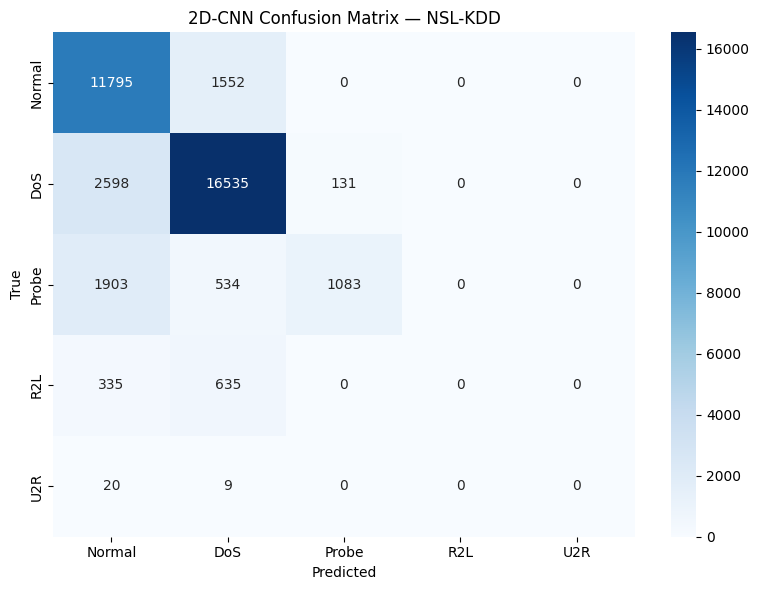

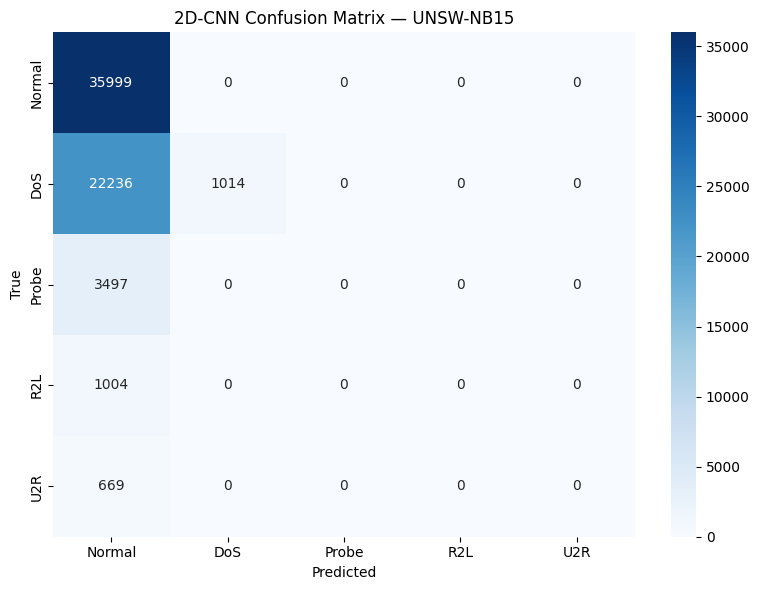

In [8]:
# 7. Evaluation
def evaluate(model, X, y, dataset):
    p = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    pred = np.argmax(p, axis=1)
    m = {
        "dataset": dataset,
        "accuracy": accuracy_score(y, pred),
        "precision_macro": precision_score(y, pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y, pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y, pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y, pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y, pred, average="weighted", zero_division=0),
    }
    print("\n", dataset)
    print(pd.Series(m).drop("dataset"))
    print("\n", classification_report(y, pred, target_names=CLASS_NAMES, zero_division=0))
    return m, pred, p, confusion_matrix(y, pred, labels=range(5))

nsl_metrics, nsl_pred, nsl_probs, cm_nsl = evaluate(
    nsl_model, X_nsl_test_img, y_nsl_test, "NSL-KDD"
)
unsw_metrics, unsw_pred, unsw_probs, cm_unsw = evaluate(
    unsw_model, X_unsw_test_img, y_unsw_test, "UNSW-NB15"
)

def save_cm(cm, title, filename):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()

save_cm(cm_nsl, "2D-CNN Confusion Matrix — NSL-KDD", "confusion_matrix_nsl.png")
save_cm(cm_unsw, "2D-CNN Confusion Matrix — UNSW-NB15", "confusion_matrix_unsw.png")

## 8. Training/validation curves

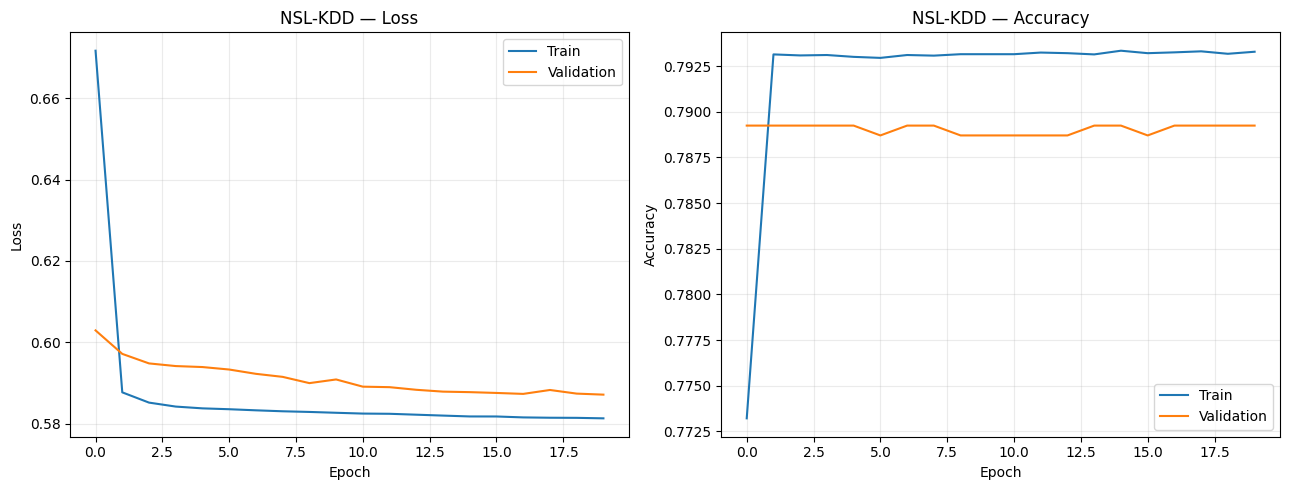

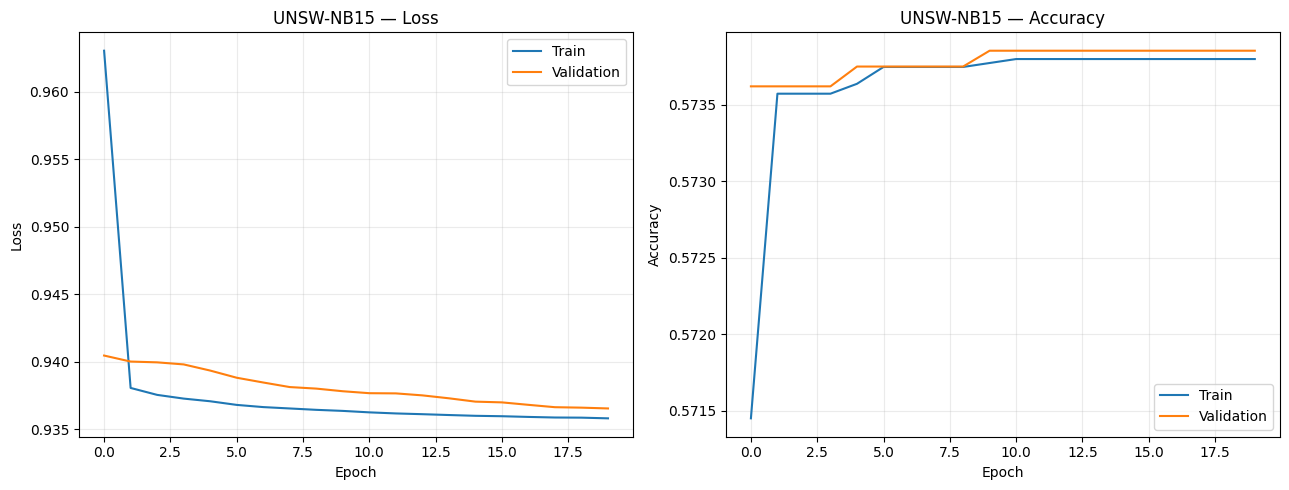

In [9]:
# 8. Training/validation curves
def plot_history(h, dataset, filename):
    fig, ax = plt.subplots(1,2, figsize=(13,5))
    ax[0].plot(h.history["loss"], label="Train")
    ax[0].plot(h.history["val_loss"], label="Validation")
    ax[0].set_title(f"{dataset} — Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
    ax[0].legend(); ax[0].grid(alpha=0.25)

    ax[1].plot(h.history["accuracy"], label="Train")
    ax[1].plot(h.history["val_accuracy"], label="Validation")
    ax[1].set_title(f"{dataset} — Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()

plot_history(history_nsl, "NSL-KDD", "training_curves_nsl.png")
plot_history(history_unsw, "UNSW-NB15", "training_curves_unsw.png")

## 9. Save outputs & create downloadable zip

Required files:
- `metrics.csv`
- `confusion_matrix_nsl.png`
- `confusion_matrix_unsw.png`
- `training_curves_nsl.png`
- `training_curves_unsw.png`

The final cell creates `cnn2d_results.zip` containing the complete `outputs/` directory and automatically downloads it in Google Colab.


In [10]:
# 9. Save outputs & create downloadable zip
metrics = pd.DataFrame([nsl_metrics, unsw_metrics])[
    ["dataset","accuracy","precision_macro","precision_weighted",
     "recall_macro","recall_weighted","f1_macro","f1_weighted"]
]
metrics.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"), index=False)

required = [
    "metrics.csv", "confusion_matrix_nsl.png", "confusion_matrix_unsw.png",
    "training_curves_nsl.png", "training_curves_unsw.png"
]
print("Output files:")
for f in required:
    print(f, "OK" if os.path.exists(os.path.join(OUTPUT_DIR,f)) else "MISSING")

ZIP_PATH = "/content/cnn2d_results.zip"
if os.path.exists(ZIP_PATH): os.remove(ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUTPUT_DIR):
        for file in files:
            full = os.path.join(root, file)
            z.write(full, os.path.relpath(full, "/content"))

print("Created:", ZIP_PATH)

try:
    from google.colab import files
    files.download(ZIP_PATH)
except ImportError:
    print("Not running in Colab. Zip saved locally at:", ZIP_PATH)

Output files:
metrics.csv OK
confusion_matrix_nsl.png OK
confusion_matrix_unsw.png OK
training_curves_nsl.png OK
training_curves_unsw.png OK
Created: /content/cnn2d_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Optional SHAP explainability

SHAP is optional and can be slow on these datasets. The example below explains a small NSL-KDD test sample. Because the CNN receives a reshaped/padded tensor, the explanation is initially over image-like positions rather than original feature names.

If you need feature-level SHAP, map the retained 36/49 positions back to the fitted preprocessing feature names and document the truncation/padding assumption.


In [11]:
# 10. Optional SHAP — uncomment to run
# !pip -q install shap
#
# import shap
#
# background = X_nsl_train_img[:50]
# explain = X_nsl_test_img[:20]
#
# def predict_flat(x):
#     x = np.asarray(x, dtype=np.float32).reshape(-1, 6, 6, 1)
#     return nsl_model.predict(x, verbose=0)
#
# explainer = shap.KernelExplainer(
#     predict_flat, background.reshape(background.shape[0], -1)
# )
# shap_values = explainer.shap_values(
#     explain.reshape(explain.shape[0], -1), nsamples=100
# )
# print("SHAP complete.")

## Replication limitations

- This is a **reimplementation/reconstruction**, not the authors' original code.
- The paper does not completely specify the preprocessing, feature-to-image ordering, padding/truncation, or every optimizer implementation detail needed for exact reproduction.
- Therefore, the assumptions in Sections 2–4 must be documented in the replication report.
- For direct comparison with your existing 1D-CNN notebook, replace the preprocessing cells with the exact 1D preprocessing code if it differs.
